# Media Contribution and Revenue Optimization Using Marketing Mix Modeling

## Executive Summary

This project estimates how selected marketing channels are associated with revenue using a Marketing Mix Modeling (MMM) workflow. The analysis uses the simulated weekly dataset from Meta Robyn and applies adstock, saturation, Ridge Regression, and a simplified grid search for transformation parameter selection. The model compares channel-level contribution signals and a simple efficiency proxy based on coefficient values relative to total spend. Because the dataset is simulated and the model is observational, the findings should be treated as model-based directional insights rather than causal proof. The workflow is designed as a transparent, end-to-end analytical project that can be reviewed, rerun, and extended.

## Business Problem and Project Objective

Marketing teams often need to understand which channels support revenue and how budget allocation could be improved across channels. Marketing Mix Modeling helps estimate the relationship between historical marketing activity, business outcomes, and contextual factors while accounting for media carryover and diminishing returns.

This project addresses three business questions:

1. Which channels have the strongest model-based contribution?
2. Which channels appear most efficient relative to total spend?
3. What budget allocation direction can be suggested based on the model?

## Data Loading and Initial Inspection

The notebook reads the processed CSV from `data/processed/robyn_mmm_weekly.csv`. The path logic below supports running the notebook either from the repository root or from the `notebooks/` directory.

In [1]:
from pathlib import Path
import os

root_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = None

for candidate in root_candidates:
    data_candidate = candidate / "data" / "processed" / "robyn_mmm_weekly.csv"
    if data_candidate.exists():
        PROJECT_ROOT = candidate.resolve()
        DATA_PATH = data_candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find data/processed/robyn_mmm_weekly.csv. "
        "Run this notebook from the repository root or the notebooks directory."
    )

OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MPLCONFIG_DIR = PROJECT_ROOT / "outputs" / "tmp" / "matplotlib"

OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from itertools import product
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

sns.set_theme(style="whitegrid")

DATA_PATH

PosixPath('/Users/adamchanuza/Desktop/marketing-mix-modeling/data/processed/robyn_mmm_weekly.csv')

In [2]:
df = pd.read_csv(DATA_PATH)

date_col = "DATE"
target_col = "revenue"

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)

df.head()

,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


In [3]:
print(f"Dataset shape: {df.shape}")
print()
print("Data types and non-null counts:")
df.info()

missing_values = df.isna().sum().reset_index()
missing_values.columns = ["Variable", "Missing Values"]
missing_values

Dataset shape: (208, 12)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DATE                208 non-null    datetime64[ns]
 1   revenue             208 non-null    float64       
 2   tv_S                208 non-null    float64       
 3   ooh_S               208 non-null    float64       
 4   print_S             208 non-null    float64       
 5   facebook_I          208 non-null    float64       
 6   search_clicks_P     208 non-null    float64       
 7   search_S            208 non-null    float64       
 8   competitor_sales_B  208 non-null    int64         
 9   facebook_S          208 non-null    float64       
 10  events              208 non-null    object        
 11  newsletter          208 non-null    float64       
dtypes: datetime64[ns](1), float64(9), int64(1), obje

,Variable,Missing Values
0,DATE,0
1,revenue,0
2,tv_S,0
3,ooh_S,0
4,print_S,0
5,facebook_I,0
6,search_clicks_P,0
7,search_S,0
8,competitor_sales_B,0
9,facebook_S,0


In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DATE,208,2017-11-16 12:00:00,2015-11-23 00:00:00,2016-11-19 06:00:00,2017-11-16 12:00:00,2018-11-13 18:00:00,2019-11-11 00:00:00,NaN
revenue,208.0,1822142.772436,672250.0,1165211.25,1874514.166667,2378407.083333,3827520.0,716228.606651
tv_S,208.0,14843.691218,0.0,0.0,0.0,18406.706667,158046.573333,28558.366546
ooh_S,208.0,43217.941026,0.0,0.0,0.0,50858.133333,500361.6,83991.426655
print_S,208.0,3728.632265,0.0,0.0,0.0,4767.833333,31922.311111,6483.070232
facebook_I,208.0,8153414.998042,0.0,0.0,0.0,13737419.399594,59432757.638193,11699127.449053
search_clicks_P,208.0,16945.206847,0.0,6280.684504,14265.252495,25236.84356,52188.128214,13614.093674
search_S,208.0,5915.512821,0.0,2353.333333,4806.666667,8536.666667,17880.0,4702.502612
competitor_sales_B,208.0,5538024.903846,2240235.0,3589581.25,5538524.0,7311814.0,9984742.0,2077191.970659
facebook_S,208.0,2145.657826,0.0,0.0,0.0,3623.012233,15400.391408,3160.363803


## Dataset and Variable Description

| Variable | Interpretation | Role in MMM |
|---|---|---|
| DATE | Weekly date variable | Time variable |
| revenue | Business outcome / revenue | Dependent variable |
| tv_S | TV spend | Paid media spend |
| ooh_S | Out-of-home spend | Paid media spend |
| print_S | Print media spend | Paid media spend |
| facebook_S | Facebook advertising spend | Paid media spend |
| facebook_I | Facebook exposure / impressions variable | Paid media exposure |
| search_S | Paid search spend | Paid media spend |
| search_clicks_P | Paid search clicks / activity variable | Paid media exposure/activity |
| competitor_sales_B | Competitor or market context indicator | Context variable |
| events | Event/category variable | Categorical context variable |
| newsletter | Organic marketing activity | Organic variable |

The Robyn demo dataset does not provide a full business data dictionary with exact units and measurement definitions. Therefore, variable interpretation in this project is based on the original Robyn input specification and naming conventions.

## Exploratory Data Analysis

The first diagnostic view checks the revenue time series to understand trend, seasonality, and visible peaks or declines before model development.

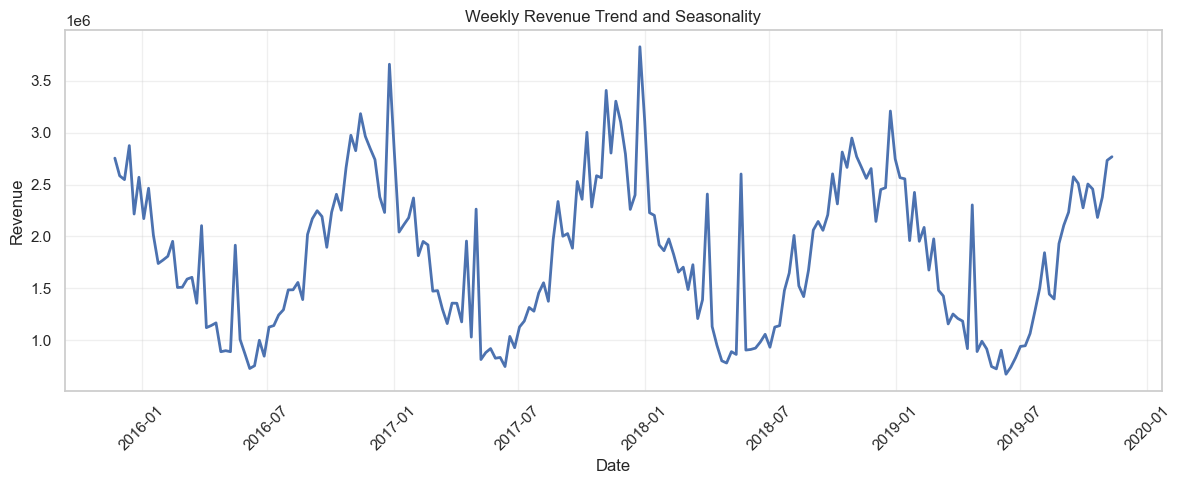

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    df[date_col],
    df[target_col],
    linewidth=2,
)

plt.title("Weekly Revenue Trend and Seasonality")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

Revenue shows cyclical and seasonal patterns across the observed weekly periods. Visible peaks and declines suggest temporal dynamics that may be related to seasonality, events, market context, and marketing activity. Time-related components should therefore be considered when interpreting MMM outputs and when extending this simplified workflow.

## Media Spend Analysis

Separate plots are used because media channels operate on different spend scales and campaign patterns. This makes individual activity patterns easier to interpret than a single combined chart.

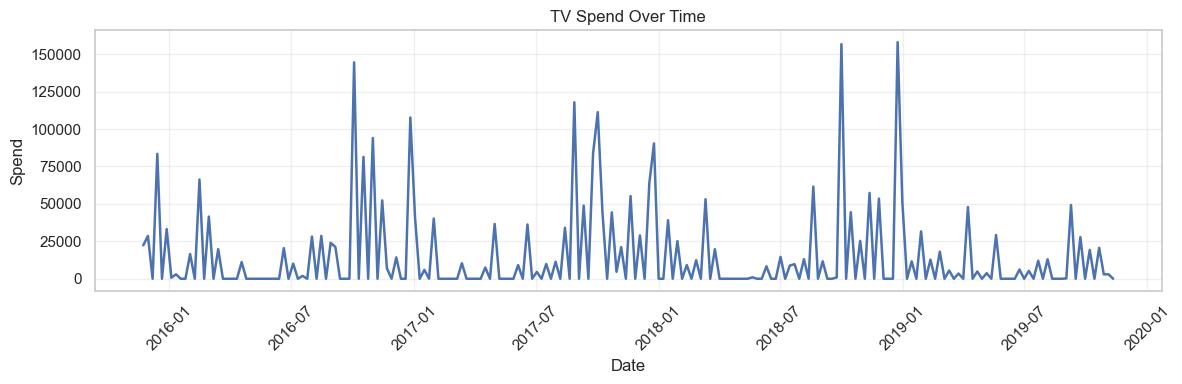

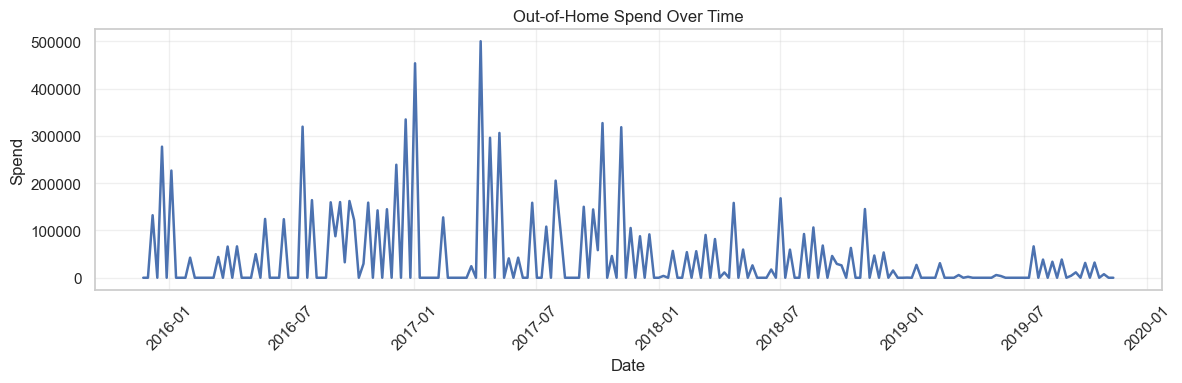

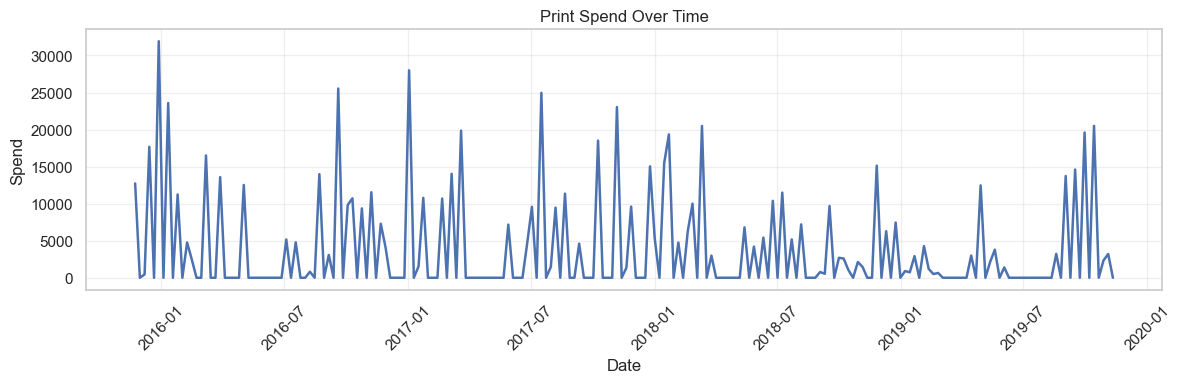

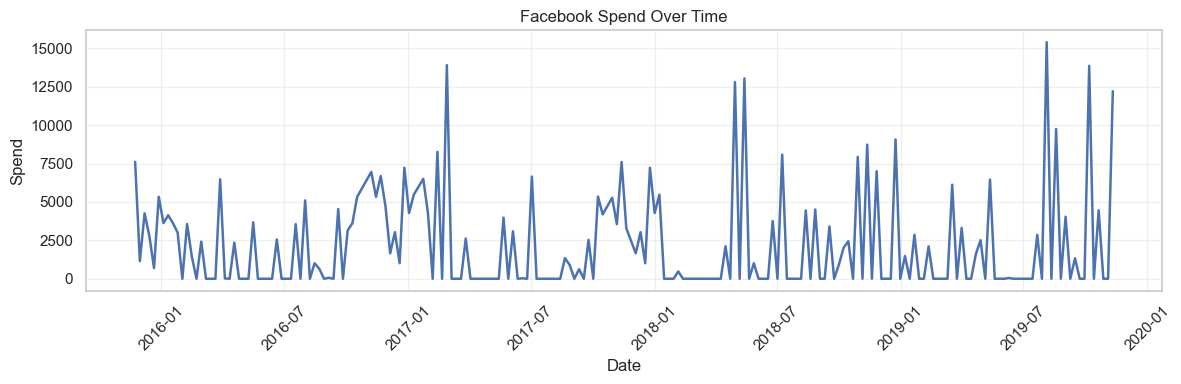

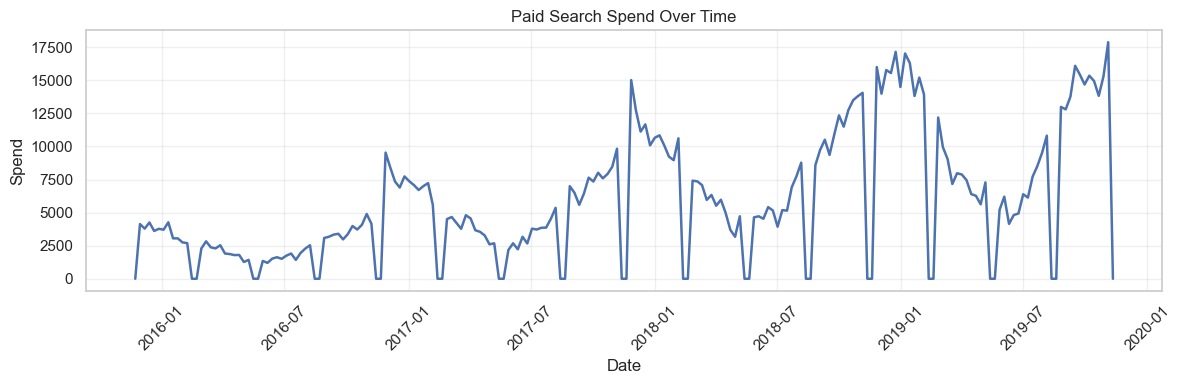

In [6]:
media_spend_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S",
]

channel_names = {
    "tv_S": "TV",
    "ooh_S": "Out-of-Home",
    "print_S": "Print",
    "facebook_S": "Facebook",
    "search_S": "Paid Search",
}

for col in media_spend_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df[date_col], df[col], linewidth=1.8)
    plt.title(f"{channel_names.get(col, col)} Spend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Spend")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / f"{col}_spend.png", dpi=150, bbox_inches="tight")
    plt.show()

## Correlation Analysis

Correlation analysis provides an initial descriptive view of linear relationships before transformations and modeling.

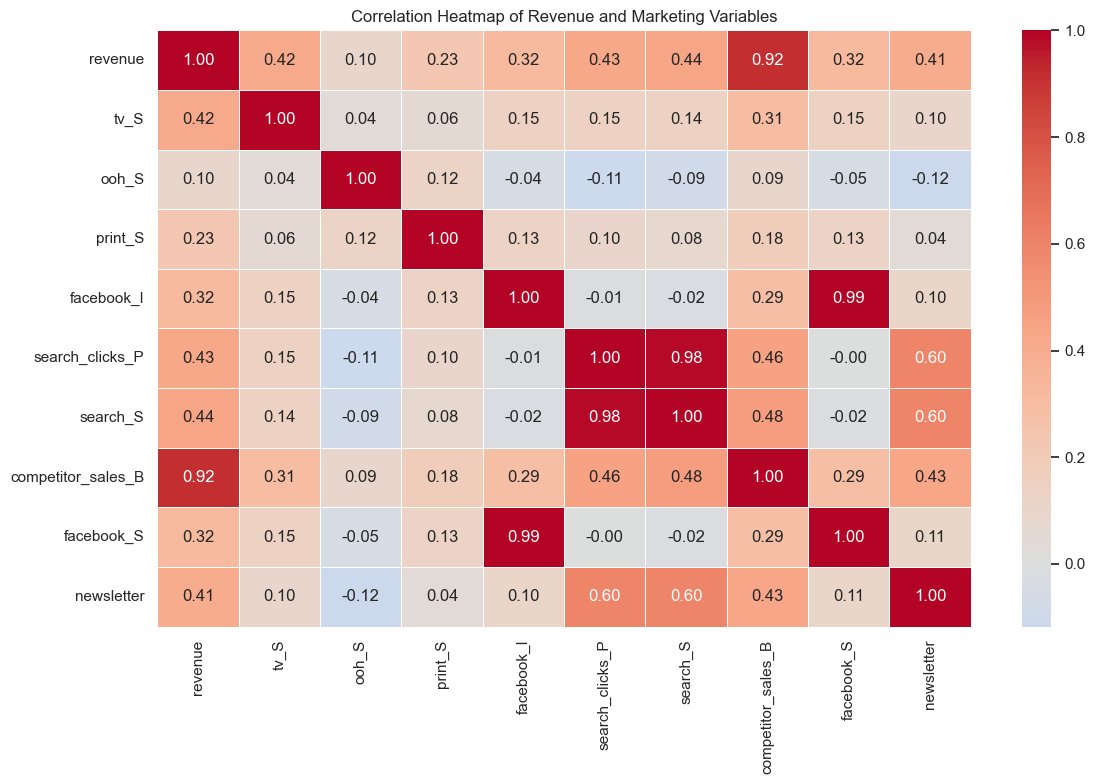

In [7]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)

plt.title("Correlation Heatmap of Revenue and Marketing Variables")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

The correlation heatmap shows initial linear relationships between revenue and marketing variables. It does not imply causality. High correlations between spend and exposure variables may indicate multicollinearity, which supports the use of Ridge Regression in this simplified MMM workflow.

## Adstock and Saturation Transformations

Adstock models media carryover effects, where a channel can continue to influence outcomes after the week in which spend occurs. Saturation models diminishing marginal returns, where additional spend may have progressively smaller incremental association with revenue. The transformation parameters are selected through simplified grid search rather than treated as known true values.

In [8]:
def apply_adstock(values, decay):
    """Apply geometric adstock to model media carryover effects."""
    x = np.asarray(values, dtype=float)
    result = np.zeros(len(x), dtype=float)

    for idx, value in enumerate(x):
        if idx == 0:
            result[idx] = value
        else:
            result[idx] = value + decay * result[idx - 1]

    return result


def apply_hill_saturation(values, alpha, gamma):
    """Apply Hill saturation to model diminishing marginal returns."""
    x = np.asarray(values, dtype=float)
    max_value = np.max(x)

    if max_value == 0:
        return x

    x_scaled = x / max_value
    numerator = x_scaled ** alpha
    denominator = numerator + gamma ** alpha

    return numerator / denominator


def add_mmm_transformations(df, media_columns, decay, alpha, gamma):
    """Add adstocked and saturated media features to a DataFrame."""
    df_transformed = df.copy()

    for col in media_columns:
        adstock_col = f"{col}_adstock"
        saturated_col = f"{col}_adstock_saturated"

        df_transformed[adstock_col] = apply_adstock(
            df_transformed[col].fillna(0).to_numpy(),
            decay=decay,
        )
        df_transformed[saturated_col] = apply_hill_saturation(
            df_transformed[adstock_col].to_numpy(),
            alpha=alpha,
            gamma=gamma,
        )

    return df_transformed

## Parameter Selection with Grid Search

This is a simplified parameter search approach. It is not a full Meta Robyn / Nevergrad optimization engine, but it improves the project by selecting adstock and saturation parameters based on validation performance rather than arbitrary fixed assumptions. The split is time-aware: the first 80% of observations are used for training and the final 20% are used for validation.

In [9]:
target_col = "revenue"

media_spend_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S",
]

control_cols = [
    "competitor_sales_B",
    "newsletter",
]

decay_values = [0.3, 0.5, 0.7]
alpha_values = [1.0, 1.5, 2.0]
gamma_values = [0.3, 0.5, 0.7]

results = []

for decay, alpha, gamma in product(decay_values, alpha_values, gamma_values):
    transformed_df = add_mmm_transformations(
        df=df,
        media_columns=media_spend_cols,
        decay=decay,
        alpha=alpha,
        gamma=gamma,
    )

    feature_cols = [
        f"{col}_adstock_saturated" for col in media_spend_cols
    ] + control_cols

    X = transformed_df[feature_cols]
    y = transformed_df[target_col]

    split_idx = int(len(transformed_df) * 0.8)
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mape = mean_absolute_percentage_error(y_test, predictions)

    results.append(
        {
            "decay": decay,
            "alpha": alpha,
            "gamma": gamma,
            "r2": r2,
            "rmse": rmse,
            "mape": mape,
        }
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
)
results_df.to_csv(OUTPUT_TABLES_DIR / "grid_search_results.csv", index=False)

results_df.head(10)

,decay,alpha,gamma,r2,rmse,mape
0,0.7,1.0,0.5,0.898562,207849.195610,0.069909
1,0.7,1.0,0.7,0.898545,207866.904794,0.071479
2,0.7,1.0,0.3,0.898082,208340.721859,0.069317
3,0.7,1.5,0.5,0.897077,209364.941005,0.077623
4,0.7,1.5,0.7,0.897020,209423.070784,0.079266
5,0.7,1.5,0.3,0.896485,209966.050966,0.074515
6,0.5,1.0,0.5,0.895963,210494.811880,0.074833
7,0.5,1.0,0.7,0.895888,210570.531722,0.076818
8,0.5,1.0,0.3,0.895817,210642.052441,0.073438
9,0.7,2.0,0.5,0.895345,211118.761921,0.083139


## Final Model Training and Evaluation

The final model uses the best parameter set from the validation grid search. In the current run, the best-performing configuration is expected to be close to decay `0.7`, alpha `1.0`, and gamma `0.5`. Results may vary slightly depending on the execution environment and library versions.

In [10]:
best_params = results_df.iloc[0]
best_decay = float(best_params["decay"])
best_alpha = float(best_params["alpha"])
best_gamma = float(best_params["gamma"])

print(f"Best decay: {best_decay}")
print(f"Best alpha: {best_alpha}")
print(f"Best gamma: {best_gamma}")

Best decay: 0.7
Best alpha: 1.0
Best gamma: 0.5


In [11]:
df_final = add_mmm_transformations(
    df=df,
    media_columns=media_spend_cols,
    decay=best_decay,
    alpha=best_alpha,
    gamma=best_gamma,
)

final_feature_cols = [
    f"{col}_adstock_saturated" for col in media_spend_cols
] + control_cols

X = df_final[final_feature_cols]
y = df_final[target_col]

split_idx = int(len(df_final) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]
date_test = df_final[date_col].iloc[split_idx:]

final_model = Ridge(alpha=1.0)
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

In [12]:
final_r2 = r2_score(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_mape = mean_absolute_percentage_error(y_test, final_predictions)

final_metrics = pd.DataFrame(
    {
        "Metric": ["R2", "RMSE", "MAPE"],
        "Value": [final_r2, final_rmse, final_mape],
    }
)
final_metrics.to_csv(OUTPUT_TABLES_DIR / "final_model_metrics.csv", index=False)

final_metrics

,Metric,Value
0,R2,0.898562
1,RMSE,207849.195610
2,MAPE,0.069909


The final model explains a substantial share of revenue variation in the validation period. In the current run, R2 is approximately 0.90 and MAPE is approximately 7%. These values should be interpreted as validation performance for this simplified model specification, not as proof that the model has identified causal effects.

## Actual vs Predicted Revenue

The next chart compares actual and predicted revenue in the validation period.

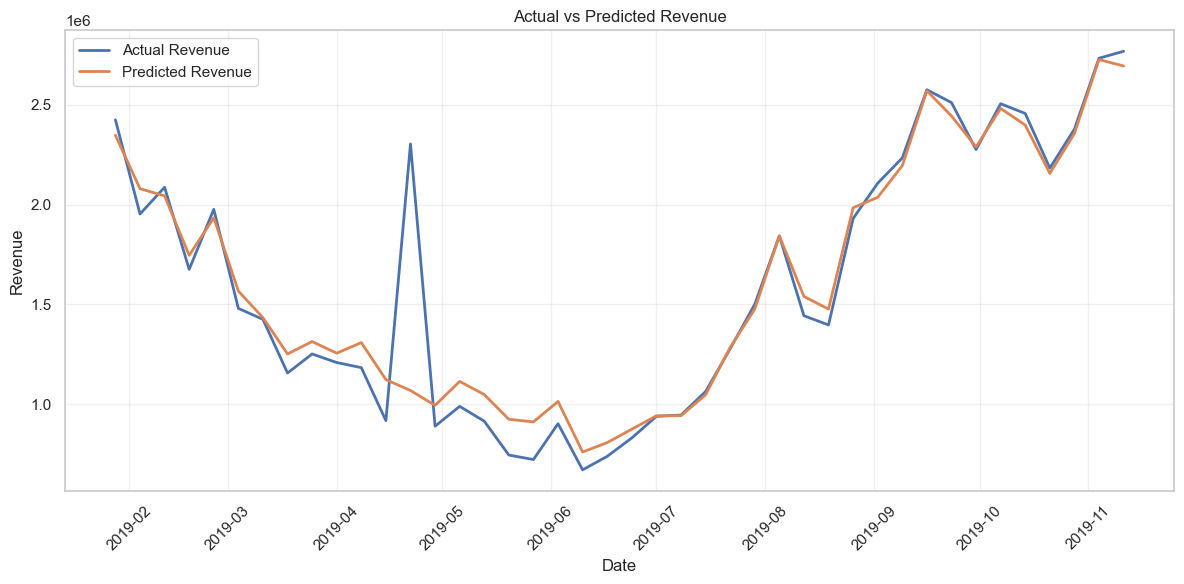

In [13]:
results_plot = pd.DataFrame(
    {
        "Date": date_test,
        "Actual Revenue": y_test.to_numpy(),
        "Predicted Revenue": final_predictions,
    }
)

plt.figure(figsize=(12, 6))

plt.plot(
    results_plot["Date"],
    results_plot["Actual Revenue"],
    label="Actual Revenue",
    linewidth=2,
)

plt.plot(
    results_plot["Date"],
    results_plot["Predicted Revenue"],
    label="Predicted Revenue",
    linewidth=2,
)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_FIGURES_DIR / "actual_vs_predicted_revenue.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

The model captures the general revenue trend well, while predictions are smoother than the actual revenue series. Sudden peaks may be harder to predict because the simplified model does not fully represent all short-term drivers, events, or unobserved external factors.

## Marketing Channel Contribution

The table and chart below summarize model coefficients for transformed media features. Coefficient values depend on the scale of transformed variables and should be interpreted as directional model-based signals rather than exact absolute revenue contribution.

In [14]:
coefficients = pd.DataFrame(
    {
        "Feature": final_feature_cols,
        "Coefficient": final_model.coef_,
    }
).sort_values("Coefficient", ascending=False)

media_coefficients = coefficients[
    coefficients["Feature"].str.endswith("_adstock_saturated")
].copy()
media_coefficients["Channel"] = media_coefficients["Feature"].str.replace(
    "_adstock_saturated",
    "",
    regex=False,
)
media_coefficients = media_coefficients[
    ["Channel", "Feature", "Coefficient"]
].sort_values("Coefficient", ascending=False)

media_coefficients.to_csv(
    OUTPUT_TABLES_DIR / "channel_contribution.csv",
    index=False,
)

media_coefficients

,Channel,Feature,Coefficient
0,tv_S,tv_S_adstock_saturated,549880.816388
3,facebook_S,facebook_S_adstock_saturated,223727.178202
1,ooh_S,ooh_S_adstock_saturated,180223.871045
2,print_S,print_S_adstock_saturated,86674.246663
4,search_S,search_S_adstock_saturated,22623.667647


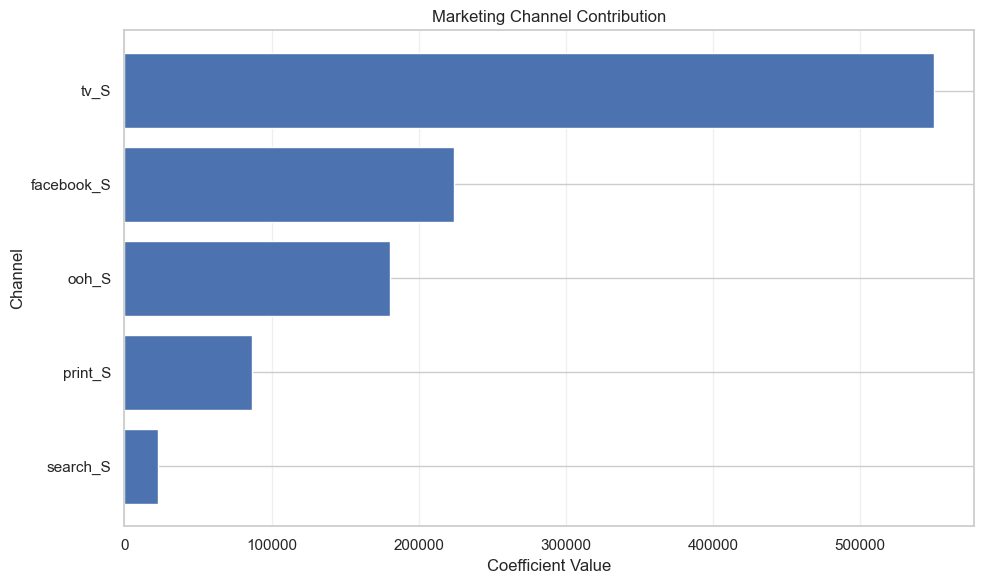

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(
    media_coefficients["Channel"],
    media_coefficients["Coefficient"],
)

plt.title("Marketing Channel Contribution")
plt.xlabel("Coefficient Value")
plt.ylabel("Channel")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "channel_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

TV shows the strongest model-based contribution signal in this specification. Facebook and OOH also show positive effects, while Print and Search have smaller positive coefficients. These are directional insights from the model, not causal proof of channel incrementality.

## Channel Efficiency Proxy

The efficiency proxy compares each transformed media coefficient with total observed spend for that channel. This is not full ROAS; it is a simplified comparison of model signal relative to total spend.

In [16]:
channel_spend_summary = pd.DataFrame(
    {
        "Channel": media_spend_cols,
        "Total Spend": [df[col].sum() for col in media_spend_cols],
    }
)
channel_spend_summary["Feature"] = [
    f"{col}_adstock_saturated" for col in media_spend_cols
]

roi_proxy = channel_spend_summary.merge(
    media_coefficients[["Feature", "Coefficient"]],
    on="Feature",
    how="left",
)
roi_proxy["Efficiency Proxy"] = (
    roi_proxy["Coefficient"] / roi_proxy["Total Spend"]
)
roi_proxy = roi_proxy.sort_values(
    "Efficiency Proxy",
    ascending=False,
).reset_index(drop=True)

roi_proxy.to_csv(
    OUTPUT_TABLES_DIR / "channel_efficiency_proxy.csv",
    index=False,
)

roi_proxy

,Channel,Total Spend,Feature,Coefficient,Efficiency Proxy
0,facebook_S,4.462968e+05,facebook_S_adstock_saturated,223727.178202,0.501297
1,tv_S,3.087488e+06,tv_S_adstock_saturated,549880.816388,0.178100
2,print_S,7.755555e+05,print_S_adstock_saturated,86674.246663,0.111758
3,ooh_S,8.989332e+06,ooh_S_adstock_saturated,180223.871045,0.020049
4,search_S,1.230427e+06,search_S_adstock_saturated,22623.667647,0.018387


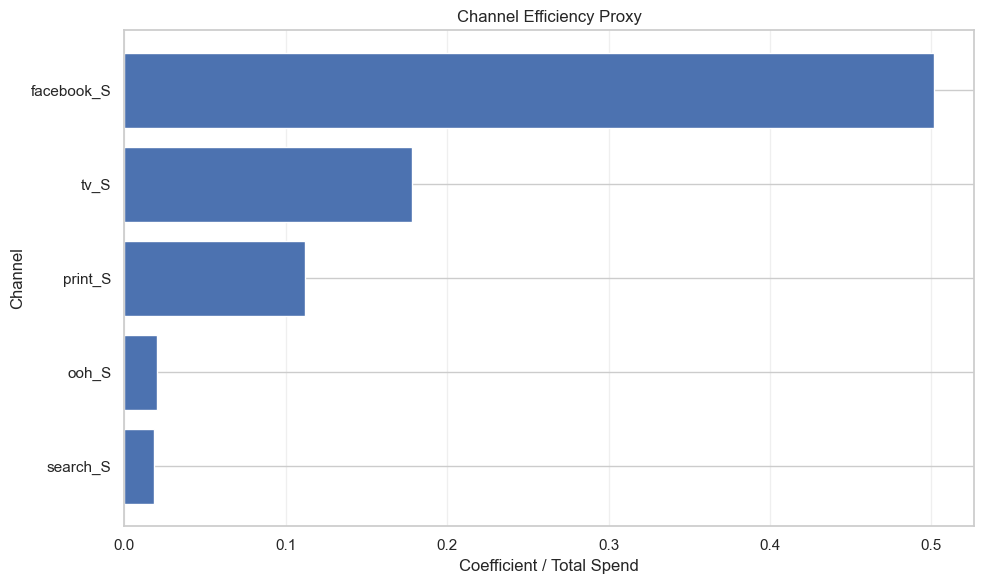

In [17]:
plt.figure(figsize=(10, 6))

plt.barh(
    roi_proxy["Channel"],
    roi_proxy["Efficiency Proxy"],
)

plt.title("Channel Efficiency Proxy")
plt.xlabel("Coefficient / Total Spend")
plt.ylabel("Channel")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_FIGURES_DIR / "channel_efficiency_proxy.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

Facebook shows the strongest efficiency proxy in this simplified specification. TV shows the strongest absolute contribution signal but lower efficiency than Facebook because total TV spend is much higher. OOH and Search appear weaker in this specification, but this should be treated as a directional signal only and not as a direct budget reallocation rule.

## Business Recommendation

TV should be maintained as a scale-building channel because it has the strongest model-based contribution signal. Facebook deserves additional attention because it combines a positive contribution signal with the strongest efficiency proxy in this simplified analysis. OOH and Search should be reviewed before increasing budget, especially because their efficiency proxies are weaker in the current model specification.

Direct budget changes should not be made from this notebook alone. The recommended decision process is to use these findings as a prioritization input, then validate them through experiments, lift tests, geo tests, or additional business review before final allocation decisions are made.

## Limitations and Next Steps

Key limitations:

- The dataset is simulated and comes from the Meta Robyn demo dataset.
- This is a simplified MMM implementation.
- The grid search is intentionally small and does not represent the full Robyn / Nevergrad optimization workflow.
- The model is not calibrated with experiments or lift tests.
- The results do not provide causal proof.
- Coefficients depend on model specification, transformations, scaling, and selected controls.
- The efficiency proxy is not full ROAS.

Recommended next steps:

- Test channel-specific decay, alpha, and gamma parameters.
- Expand the parameter search space.
- Use rolling or time-series cross-validation.
- Compare Ridge Regression with other model classes.
- Build a more complete contribution decomposition.
- Add budget allocation simulation.
- Calibrate model outputs with lift tests, geo experiments, or other incrementality evidence.

## Final Summary

This project built an end-to-end Marketing Mix Modeling workflow using the simulated weekly Meta Robyn dataset. The analysis loaded and inspected the data, reviewed revenue seasonality and media spend patterns, and evaluated correlations between numeric variables. Media spend variables were transformed with adstock and Hill saturation, and a simplified grid search selected the transformation parameters used in the final Ridge Regression model. The final validation performance was approximately 0.90 R2 with MAPE around 7%, depending on execution details. TV had the strongest model-based contribution signal, while Facebook had the strongest efficiency proxy. These findings are directional and should be validated with stronger experimental or business evidence before budget decisions are made.